### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [26]:
titanic = sns.load_dataset('titanic')

print(titanic.columns)
print(titanic.info())
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [27]:
# describe(): 데이터프레임의 숫자형(numeric) 컬럼들에 대한 기술통계(descriptive statistics)를 한 번에 뽑아주는 함수
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
# sum의 axis기본값 0 : sum(axis=0)
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [29]:
# titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# pandas 3.0부터 아래 문법으로 변경됨
# fillna(): 결측치(NaN, 값이 없는 셀)를 원하는 값으로 채워주는 함수
titanic.fillna({'age': titanic['age'].mean()}, inplace=True)

# 나중에 경고 뜨면 inplace=True 관련 에러뜨면 아래처럼 변경
# titanic['age'] = titanic['age'].fillna(titanic['age'].mean())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [30]:
titanic['age'].isnull().sum()

np.int64(0)

In [31]:
titanic['embarked'].value_counts()
# titanic['embarked'].isnull().sum()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [32]:
titanic.fillna({'embarked': 'N'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [33]:
# 첫 실행에만 에러 안남
# 두 번 실행하면 이미 N 카테고리가 존재하는데 또 추가하려고 해서 에러남
titanic['deck'] = titanic['deck'].cat.add_categories('N')

titanic.fillna({'deck': 'N'}, inplace=True)
titanic['deck'].isnull().sum()

# print(titanic['deck'])

np.int64(0)

In [34]:
titanic['deck'].value_counts()

deck
N    688
C     59
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [35]:
pd.__version__

'3.0.5'

In [36]:
titanic.fillna({'embark_town': 'N'}, inplace=True)
titanic['embark_town'].isnull().sum()

np.int64(0)

In [37]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [38]:
# 남,여 탑승 수
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [39]:
print(dir(titanic))

# 생존율 0(사망): 549, 1(생존): 342
titanic['survived'].value_counts()

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod_

survived
0    549
1    342
Name: count, dtype: int64

In [41]:
# 성별 생존여부
# titanic.groupby(['sex'])
titanic.groupby(['sex'])['survived'].value_counts()
# titanic.groupby(['sex', 'survived'])['survived'].count()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

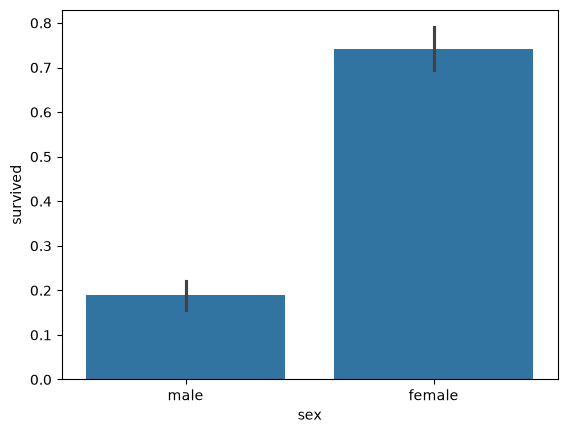

In [42]:
sns.barplot(data=titanic, x='sex', y='survived')

https://pandas.pydata.org/docs/reference/api/pandas.Series.cat.html#pandas.Series.cat

### 객실 등급별 성별에 따른 생존 확률
* 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.
* 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.
* 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다. 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

<Axes: xlabel='pclass', ylabel='survived'>

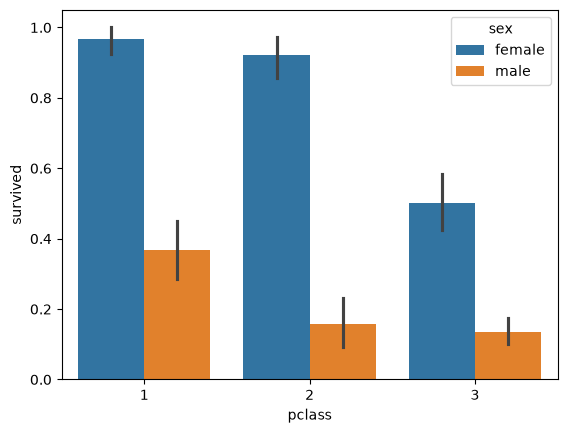

In [43]:
# 선실등급별 남여 생존여부
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

In [44]:
X_train, X_test, y_train, y_test = train_test_split(titanic.loc[:, 'pclass': 'alone'], titanic['survived'], random_state=11)

In [45]:
import platform
import sklearn

if platform.system() == 'Windows':
    sklearn.set_config(display='text')

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train) # ValueError: could not convert string to float: 'male'
# 로지스틱 회귀는 내부적으로 **수학 연산(곱셈, 덧셈 — 가중치×값)**으로 예측을 계산해요. 
# 'male', 'female' 같은 문자열은 수학 연산이 불가능하니까, fit() 호출하는 순간 "이 문자열을 숫자로 못 바꾸겠다"고 에러를 내는 거예요.
# 모든 컬럼을 다 바꿔야 하냐? → X_train에 들어있는 문자열 컬럼만

ValueError: could not convert string to float: 'male'

In [46]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

### LabelEncoder() 로 인코딩

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()

# 변환할 컬럼 목록 (str, category)
label_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

for col in label_cols:
    titanic_df1[col] = le.fit_transform(titanic_df1[col])

In [48]:
titanic_df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10), str(1)
memory usage: 92.4 KB


In [49]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,3,2,1,7,3
1,0,0,0,2,2,0
2,0,3,2,2,7,3
3,0,3,0,2,2,3
4,1,3,2,1,7,3


In [50]:
print(titanic['sex'].head())
print(titanic_df1['sex'].head())

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: str
0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


In [51]:
titanic_df1['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [52]:
titanic_df1['deck'].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

### OneHotEncoder(sparse_output=False, handle_unknown='ignore')

| 파라미터                      | 설명                                                                            |
| ------------------------- | ----------------------------------------------------------------------------- |
| `sparse_output=False`     | 반환값을 **희소 행렬(sparse matrix)** 대신 **NumPy 배열**로 반환. <br> → DataFrame으로 변환하기 쉬움 |
| `handle_unknown='ignore'` | 학습 시 보지 못한 **새로운 범주가 등장해도 에러 없이 무시**. <br> → 안정적인 예측 및 인코딩 수행                 |


In [53]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

titanic_df2 = titanic.copy()

# 변환할 컬럼 목록
ohe_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

ohe_result = pd.DataFrame(index = titanic_df2.index)
print(f'ohe_result: {ohe_result.head()}')
print(f'ohe_result_len: {len(ohe_result)}')

for col in ohe_cols:
    encoded = ohe.fit_transform(titanic_df2[[col]])
    # print(encoded)

    col_names = ohe.get_feature_names_out([col])
    # print(col_names) # ['sex_female', 'sex_male']

    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df2.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)
    # print(ohe_result.head())
    # break

ohe_result: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
ohe_result_len: 891


In [54]:
print(len(ohe_result.columns))
ohe_result.head()


24


,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [55]:
titanic_df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [56]:
# survived와 alive 컬럼 2개가 생존여부를 의미한다. 그래서 alive 컬럼을 삭제한다.
titanic_df2.drop(columns=['alive'], inplace=True)

In [57]:
titanic_df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [58]:
# 2번 이상 수행하면 에러뜸
# titanic_df2 = pd.concat([titanic_df2.drop(columns=ohe_cols)])

# 이미 삭제했기에 2번 수행하면 에러뜸
titanic_df2.drop(columns=ohe_cols, inplace=True)

In [59]:
titanic_df2

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.000000,1,0,7.2500,True,False
1,1,1,38.000000,1,0,71.2833,False,False
2,1,3,26.000000,0,0,7.9250,False,True
3,1,1,35.000000,1,0,53.1000,False,False
4,0,3,35.000000,0,0,8.0500,True,True
...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,True,True
887,1,1,19.000000,0,0,30.0000,False,True
888,0,3,29.699118,1,2,23.4500,False,False
889,1,1,26.000000,0,0,30.0000,True,True


In [60]:
# 원-핫 인코딩이랑 변경한 컬럼이랑 합치기
titanic_df2 = pd.concat([titanic_df2, ohe_result], axis=1)

In [61]:
print(titanic_df2.columns)
titanic_df2.head(1)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N',
       'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='str')


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.25,True,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `alive`       | str   | LabelEncoder  | yes/no → 이진             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |


In [62]:
titanic_df3 = titanic.copy()

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alone']
le = LabelEncoder()

for col in label_cols:
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과를 저장할 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols:
    #encoded 타입은 ndarray
    encoded = ohe.fit_transform(titanic_df3[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df3.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

# 기존 원본 컬럼 삭제 후 병합
titanic_df3 = pd.concat([titanic_df3.drop(columns=ohe_cols), ohe_result], axis=1)
print(titanic_df3.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 891 non-null    int64  
 1   pclass                   891 non-null    int64  
 2   age                      891 non-null    float64
 3   sibsp                    891 non-null    int64  
 4   parch                    891 non-null    int64  
 5   fare                     891 non-null    float64
 6   class                    891 non-null    int64  
 7   adult_male               891 non-null    int64  
 8   alive                    891 non-null    str    
 9   alone                    891 non-null    int64  
 10  sex_female               891 non-null    float64
 11  sex_male                 891 non-null    float64
 12  embarked_C               891 non-null    float64
 13  embarked_N               891 non-null    float64
 14  embarked_Q               891 non-null

In [63]:
titanic_df3.drop(columns=['alive'], inplace=True)

In [64]:
titanic_df3

,survived,pclass,age,sibsp,parch,fare,class,adult_male,alone,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,who_child,who_man,who_woman,deck_A,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.000000,1,0,7.2500,2,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,1,38.000000,1,0,71.2833,0,0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.000000,0,0,7.9250,2,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1,1,35.000000,1,0,53.1000,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,3,35.000000,0,0,8.0500,2,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
887,1,1,19.000000,0,0,30.0000,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
888,0,3,29.699118,1,2,23.4500,2,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
889,1,1,26.000000,0,0,30.0000,0,1,1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.

make_column_transformer를 이용한 인코딩
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

# make_column_transformer

- -> 서로 다른 컬럼에 서로 다른 전처리를 한 번에 적용해주는 sklearn 도구

In [65]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()

In [66]:
titanic_df4.drop(columns=['alive'], inplace=True)

In [67]:
titanic_df4.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='str')

In [68]:
# 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class', 'adult_male', 'alone']

# make_column_transformer
column_transformer = make_column_transformer((OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols), 
                                             (OrdinalEncoder(), ordinal_cols), 
                                             remainder='passthrough')

# 변환 적용
encoded = column_transformer.fit_transform(titanic_df4)

In [69]:
# encoded
# titanic_df4

# 컬럼 이름 추출
print(dir(column_transformer))
print(column_transformer.named_transformers_)
print()

onehot_feature_names = column_transformer.named_transformers_['onehotencoder'].get_feature_names_out(onehot_cols)
print('onehot_feature_names:')
print(type(onehot_feature_names))
print(onehot_feature_names)
print()

ordinal_feature_names = ordinal_cols
print('ordinal_feature_names:')
print(type(ordinal_feature_names))
print(ordinal_feature_names)
print()

# 이 부분을 2번이상 실행하면 에러남
other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols]
print('other_feature_name:')
print(type(other_feature_name))
print(other_feature_name)
print()

# onehot_feature_names의 타입이 numpy.ndarray여서 list로 변환
final_feature_names = other_feature_name + list(onehot_feature_names) + ordinal_feature_names
print('final_feature_names:')
print(final_feature_names)
print()


# DataFrame으로 변환
titanic_df4 = pd.DataFrame(encoded, columns=final_feature_names, index=titanic_df4.index)
print(titanic_df4.head())


['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_add_prefix_for_feature_names_out', '_call_func_on_transformers', '_check_estimators_are_instances', '_columns', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_get_class_level_metadata_request_values', '_get_doc_link', '_get_empty_routing', '_get_feature_name_out_for_transformer', '_get_fitted_attr_html', '_get_metadata_request', '_get_param_names', '_get_params', '_get_params_html', '_get_remainder_cols', '_get_remainder_cols_dtype', '_hstack', '_html_repr', '_iter', '_log_me

In [70]:
feature_names = column_transformer.get_feature_names_out()
print(feature_names)

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(encoded_df)

['onehotencoder__sex_female' 'onehotencoder__sex_male'
 'onehotencoder__embarked_C' 'onehotencoder__embarked_N'
 'onehotencoder__embarked_Q' 'onehotencoder__embarked_S'
 'onehotencoder__who_child' 'onehotencoder__who_man'
 'onehotencoder__who_woman' 'onehotencoder__deck_A'
 'onehotencoder__deck_B' 'onehotencoder__deck_C' 'onehotencoder__deck_D'
 'onehotencoder__deck_E' 'onehotencoder__deck_F' 'onehotencoder__deck_G'
 'onehotencoder__deck_N' 'onehotencoder__embark_town_Cherbourg'
 'onehotencoder__embark_town_N' 'onehotencoder__embark_town_Queenstown'
 'onehotencoder__embark_town_Southampton' 'ordinalencoder__class'
 'ordinalencoder__adult_male' 'ordinalencoder__alone'
 'remainder__survived' 'remainder__pclass' 'remainder__age'
 'remainder__sibsp' 'remainder__parch' 'remainder__fare']
     onehotencoder__sex_female  ...  remainder__fare
0                          0.0  ...           7.2500
1                          1.0  ...          71.2833
2                          1.0  ...           7

In [71]:
titanic_df5 = titanic.copy()
column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder='passthrough',
    verbose_feature_names_out=False # 접두사 제거 옵션
)

encoded = column_transformer_ignore.fit_transform(titanic_df5)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded, columns=feature_names)
print(f'encoded_df: {encoded_df.columns}')
print(encoded_df)

encoded_df: Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare', 'alive'],
      dtype='str')
    sex_female sex_male embarked_C embarked_N  ... sibsp parch     fare alive
0          0.0      1.0        0.0        0.0  ...     1     0     7.25    no
1          1.0      0.0        1.0        0.0  ...     1     0  71.2833   yes
2          1.0      0.0        0.0        0.0  ...     0     0    7.925   yes
3          1.0      0.0        0.0        0.0  ...     1     0     53.1   yes
4          0.0      1.0        0.0        0.0  ...     0     0     8.05    no
..         ...      ...        ...        ...  ...   ...   ...      

ColumnTransformer는 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [92]:
from sklearn.compose import ColumnTransformer

titanic_df5 = titanic.copy()
titanic_df5.drop(columns=['alive'], inplace=True)

In [93]:
titanic_df5.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,N,Southampton,False


In [ ]:
# 2번 이상 실행 시 에러남
# 정답으로 사용될 컬럼이라 따로 뺌
target = titanic_df5['survived']
target

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [95]:
titanic_df5 = titanic_df5.iloc[:, 1:] # titanic_df5['sex'] titanic_df5[['sex', 'embarked', 'who']]

# 2. 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class',  'adult_male', 'alone']

# 3. ColumnTransformer 정의
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

# 4. 변환 실행
encoded_array = ct.fit_transform(titanic_df5)

# 5. 변환된 컬럼명 추출 및 DataFrame 생성
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)

# print(encoded_df.head())

In [96]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='str')


In [125]:
# train_test_split(학습할 데이터, 정답, )
X_train, X_test, y_train, y_test = train_test_split(encoded_df, target, test_size=0.25, stratify=target, random_state=42) # suffle=True -> 섞어서 가져오기

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')
print()

# 훈련데이터와 테스트데이터의 배율은 동일해야함.
#    훈련 데이터
# 0  20   10
# 1  10    5 
# --> 이렇게 훈련데이터가 10, 20 이여서 2배인것처럼 데이터도 5, 10 이렇게 2배여야함
print(f'train: {y_train.value_counts()}')
print()
print(f'test: {y_test.value_counts()}')

X_train: (668, 29)
X_test: (223, 29)
y_train: (668,)
y_test: (223,)

train: survived
0    412
1    256
Name: count, dtype: int64

test: survived
0    137
1     86
Name: count, dtype: int64


In [126]:
# LogisticRegression 알고리즘
model = LogisticRegression(max_iter=1000)

# 훈련
model.fit(X_train, y_train)

# 테스트
y_pred = model.predict(X_test)

In [127]:
# 혼동행렬
confusion_matrix(y_test, y_pred)

array([[115,  22],
       [ 20,  66]])

In [128]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       137
           1       0.75      0.77      0.76        86

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



In [130]:
# 평가지표
print('평가지표')
print(f'Accuracy : {accuracy_score(y_test, y_pred)}')
print(f'Precision : {precision_score(y_test, y_pred)}')
print(f'Recall : {recall_score(y_test, y_pred)}')
print(f'F1 Score : {f1_score(y_test, y_pred)}')

평가지표
Accuracy : 0.8116591928251121
Precision : 0.75
Recall : 0.7674418604651163
F1 Score : 0.7586206896551724
